# Apartment Price Prediction

Machine learning project for predicting apartment prices and classifying apartments by price range.

## 1. Introduction

The objective of this project is to explore machine learning models for apartment price prediction.

The original problem is a regression task because the target variable, `last_price`, is numerical. For learning purposes, the problem is also transformed into a binary classification task, where apartments are divided into two price categories.

The project covers data preparation, classification, regression, model evaluation, hyperparameter tuning, and final model selection.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import accuracy_score, mean_squared_error

In [4]:
df = pd.read_csv("../data/moved_train_data_us.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (6495, 14)
   last_price  total_area  bedrooms  ceiling_height  floors_total  \
0    108000.0        59.0         2            2.87             4   
1    264000.0       109.0         4            3.15             5   
2    140000.0        74.5         3            2.58            10   
3     64000.0        37.4         1            2.50             9   
4    133000.0        64.9         3            2.65            12   

   living_area  floor  bike_parking  studio  open_plan  kitchen_area  balcony  \
0         31.5      2             0       0          0           6.6        0   
1         72.0      2             0       0          0          12.2        0   
2         49.0      9             0       0          0          10.8        0   
3         20.0      4             0       0          0           6.2        2   
4         41.9     11             0       0          0          10.4        0   

   airports_nearest  cityCenters_nearest  
0             20485          

In [5]:
print("Columnas:")
print(df.columns.tolist())

print("\nInformación del dataset:")
df.info()

Columnas:
['last_price', 'total_area', 'bedrooms', 'ceiling_height', 'floors_total', 'living_area', 'floor', 'bike_parking', 'studio', 'open_plan', 'kitchen_area', 'balcony', 'airports_nearest', 'cityCenters_nearest']

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 6495 entries, 0 to 6494
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   last_price           6495 non-null   float64
 1   total_area           6495 non-null   float64
 2   bedrooms             6495 non-null   int64  
 3   ceiling_height       6495 non-null   float64
 4   floors_total         6495 non-null   int64  
 5   living_area          6495 non-null   float64
 6   floor                6495 non-null   int64  
 7   bike_parking         6495 non-null   int64  
 8   studio               6495 non-null   int64  
 9   open_plan            6495 non-null   int64  
 10  kitchen_area         6495 non-null   float64
 11  balco

In [6]:
print(df.describe())

         last_price   total_area     bedrooms  ceiling_height  floors_total  \
count  6.495000e+03  6495.000000  6495.000000     6495.000000   6495.000000   
mean   1.610057e+05    65.588209     2.239569        2.780531     10.855427   
std    2.351729e+05    39.630351     1.163771        0.687026      6.053443   
min    2.438000e+02    17.000000     1.000000        1.000000      1.000000   
25%    8.700000e+04    42.500000     1.000000        2.550000      5.000000   
50%    1.130000e+05    56.200000     2.000000        2.700000      9.000000   
75%    1.660000e+05    75.150000     3.000000        2.850000     15.500000   
max    8.400000e+06   900.000000    16.000000       27.500000     52.000000   

       living_area        floor  bike_parking  studio  open_plan  \
count  6495.000000  6495.000000   6495.000000  6495.0     6495.0   
mean     38.019549     5.922248      0.002309     0.0        0.0   
std      25.101307     4.635593      0.048005     0.0        0.0   
min       3.0000

## 3.1 Price Distribution

The target variable `last_price` represents the selling price of each apartment.

Before training any model, we examine its distribution to understand its scale and identify potential outliers.

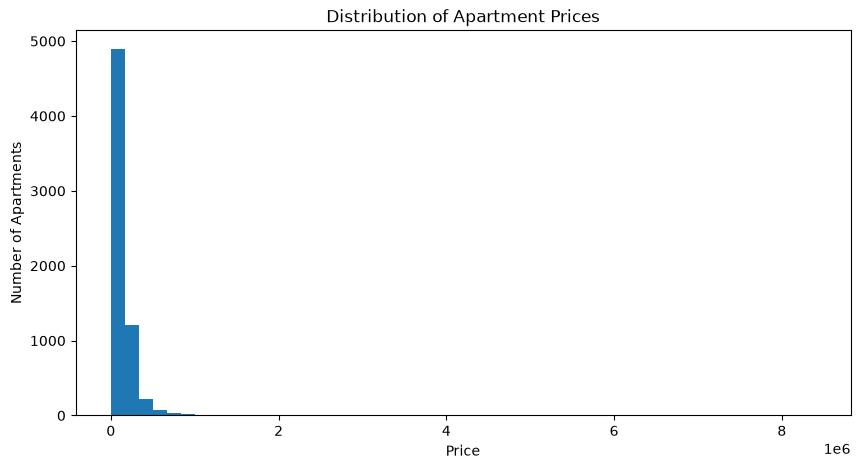

In [7]:
plt.figure(figsize=(10, 5))

plt.hist(df["last_price"], bins=50)

plt.title("Distribution of Apartment Prices")
plt.xlabel("Price")
plt.ylabel("Number of Apartments")

plt.show()

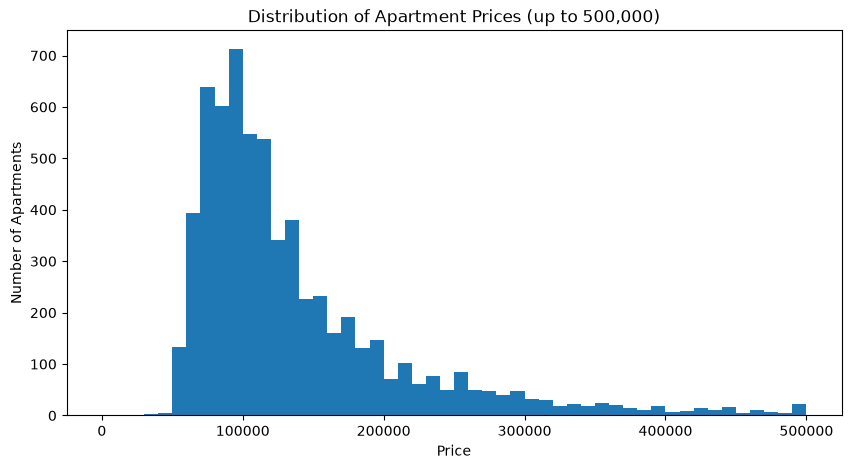

In [8]:
plt.figure(figsize=(10, 5))

plt.hist(df["last_price"], bins=50, range=(0, 500000))

plt.title("Distribution of Apartment Prices (up to 500,000)")
plt.xlabel("Price")
plt.ylabel("Number of Apartments")

plt.show()

## 3.2 Price and Apartment Area

Apartment size is expected to be one of the main factors associated with price. We examine the relationship between `total_area` and `last_price`.

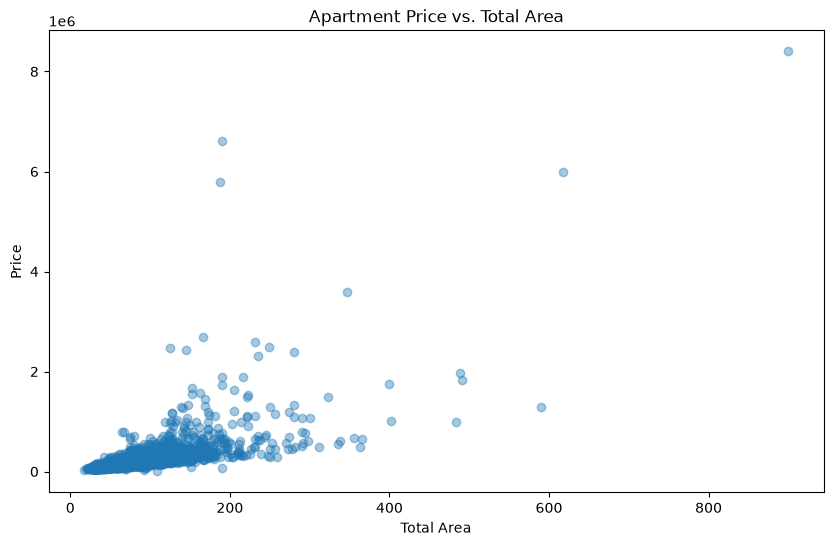

In [9]:
plt.figure(figsize=(10, 6))

plt.scatter(df["total_area"], df["last_price"], alpha=0.4)

plt.title("Apartment Price vs. Total Area")
plt.xlabel("Total Area")
plt.ylabel("Price")

plt.show()

## 3.4 Data Preparation

Two variables, `studio` and `open_plan`, contain only one unique value in the dataset. Since they provide no variation, they cannot help distinguish between apartments and are removed before modeling.

In [10]:
df = df.drop(["studio", "open_plan"], axis=1)

print("Dataset shape:", df.shape)
print(df.columns.tolist())

Dataset shape: (6495, 12)
['last_price', 'total_area', 'bedrooms', 'ceiling_height', 'floors_total', 'living_area', 'floor', 'bike_parking', 'kitchen_area', 'balcony', 'airports_nearest', 'cityCenters_nearest']


## 3.5 Classification Target

Although apartment price is naturally a regression target, we also formulate a binary classification problem.

The median apartment price is $113,000. Apartments priced above this value are assigned to class `1`, while apartments priced at or below this value are assigned to class `0`.

In [11]:
df["price_class"] = (df["last_price"] > 113000).astype(int)

print(df[["last_price", "price_class"]].head(10))

   last_price  price_class
0    108000.0            0
1    264000.0            1
2    140000.0            1
3     64000.0            0
4    133000.0            1
5     94000.0            0
6    175000.0            1
7    152000.0            1
8     63800.0            0
9    110000.0            0


In [12]:
class_counts = df["price_class"].value_counts()

print(class_counts)
print()
print("Proporciones:")
print(df["price_class"].value_counts(normalize=True))

price_class
0    3258
1    3237
Name: count, dtype: int64

Proporciones:
price_class
0    0.501617
1    0.498383
Name: proportion, dtype: float64


# 4. Classification

We first formulate apartment price prediction as a binary classification problem.

The objective is to predict whether an apartment belongs to the lower-price class (`0`) or higher-price class (`1`) using its characteristics.

## 4.1 Features and Target

The original price (`last_price`) is excluded from the features because `price_class` was derived directly from it. Including it would cause data leakage.

In [13]:
features = df.drop(["last_price", "price_class"], axis=1)
target = df["price_class"]

print("Features shape:", features.shape)
print("Target shape:", target.shape)

Features shape: (6495, 11)
Target shape: (6495,)


## 4.2 Train-Validation Split

We split the dataset into training and validation sets. The training set is used to fit the models, while the validation set is used to evaluate their ability to generalize to unseen data.

In [14]:
features_train, features_valid, target_train, target_valid = train_test_split(
    features,
    target,
    test_size=0.25,
    random_state=12345
)

print("Training set:", features_train.shape)
print("Validation set:", features_valid.shape)

Training set: (4871, 11)
Validation set: (1624, 11)


## 4.3 Decision Tree Classifier

A decision tree classifies observations by creating a sequence of decision rules based on the input features.

We begin with the default model and then investigate how the `max_depth` hyperparameter affects performance.

In [15]:
model = DecisionTreeClassifier(random_state=12345)

model.fit(features_train, target_train)

train_predictions = model.predict(features_train)
valid_predictions = model.predict(features_valid)

train_accuracy = accuracy_score(target_train, train_predictions)
valid_accuracy = accuracy_score(target_valid, valid_predictions)

print("Training accuracy:", train_accuracy)
print("Validation accuracy:", valid_accuracy)

Training accuracy: 1.0
Validation accuracy: 0.853448275862069


## 4.4 max_depth

In [16]:
depth_results = []

for depth in range(1, 11):
    model = DecisionTreeClassifier(
        random_state=12345,
        max_depth=depth
    )
    
    model.fit(features_train, target_train)
    
    train_accuracy = accuracy_score(
        target_train,
        model.predict(features_train)
    )
    
    valid_accuracy = accuracy_score(
        target_valid,
        model.predict(features_valid)
    )
    
    depth_results.append({
        "max_depth": depth,
        "train_accuracy": train_accuracy,
        "validation_accuracy": valid_accuracy
    })

depth_results = pd.DataFrame(depth_results)

print(depth_results)

   max_depth  train_accuracy  validation_accuracy
0          1        0.840690             0.852217
1          2        0.840690             0.852217
2          3        0.858345             0.846675
3          4        0.876617             0.872537
4          5        0.895915             0.866379
5          6        0.906179             0.870690
6          7        0.920345             0.866379
7          8        0.932868             0.870690
8          9        0.949497             0.862685
9         10        0.963457             0.863916


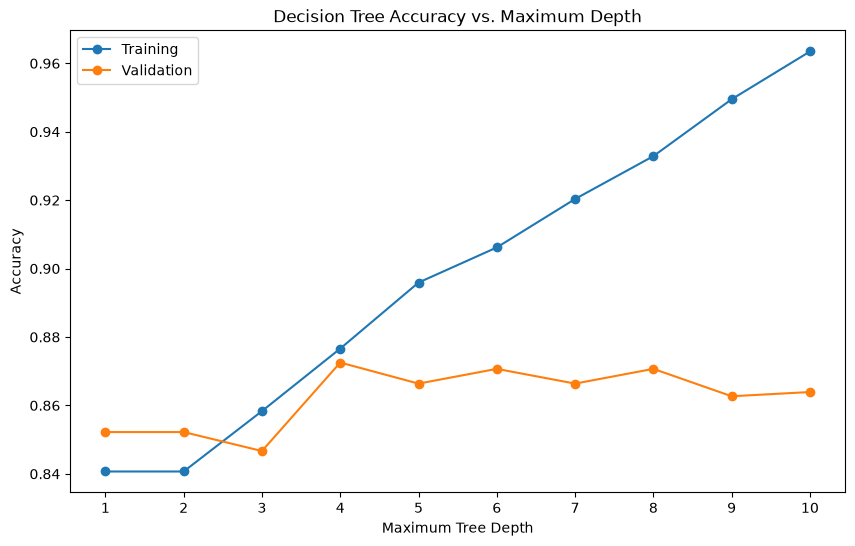

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    depth_results["max_depth"],
    depth_results["train_accuracy"],
    marker="o",
    label="Training"
)

plt.plot(
    depth_results["max_depth"],
    depth_results["validation_accuracy"],
    marker="o",
    label="Validation"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs. Maximum Depth")
plt.xticks(range(1, 11))
plt.legend()

plt.show()

## 4.5 Random Forest Classifier

A random forest combines multiple decision trees. Each tree is trained using a different subset of the data and features, and their predictions are combined to produce the final classification.

We evaluate different numbers of trees (`n_estimators`) using the validation set.

In [18]:
forest_results = []

for est in range(10, 101, 10):
    model = RandomForestClassifier(
        random_state=54321,
        n_estimators=est
    )
    
    model.fit(features_train, target_train)
    
    train_accuracy = accuracy_score(
        target_train,
        model.predict(features_train)
    )
    
    valid_accuracy = accuracy_score(
        target_valid,
        model.predict(features_valid)
    )
    
    forest_results.append({
        "n_estimators": est,
        "train_accuracy": train_accuracy,
        "validation_accuracy": valid_accuracy
    })

forest_results = pd.DataFrame(forest_results)

print(forest_results)

   n_estimators  train_accuracy  validation_accuracy
0            10        0.990556             0.897167
1            20        0.996715             0.894089
2            30        0.999179             0.899631
3            40        0.999589             0.897167
4            50        0.999384             0.900862
5            60        0.999795             0.902094
6            70        1.000000             0.903941
7            80        1.000000             0.901478
8            90        1.000000             0.902094
9           100        1.000000             0.902709


In [19]:
best_forest = forest_results.loc[
    forest_results["validation_accuracy"].idxmax()
]

print("Best Random Forest:")
print(best_forest)

Best Random Forest:
n_estimators           70.000000
train_accuracy          1.000000
validation_accuracy     0.903941
Name: 6, dtype: float64


## 4.6 Logistic Regression

Logistic regression is a classification algorithm that estimates the probability of belonging to a class.

Unlike a decision tree or random forest, it uses a linear relationship between the input features and the log-odds of the target class.

We use it as a simpler baseline to compare against the tree-based models.

In [20]:
logistic_model = LogisticRegression(
    random_state=54321,
    solver="liblinear"
)

logistic_model.fit(features_train, target_train)

logistic_train_accuracy = accuracy_score(
    target_train,
    logistic_model.predict(features_train)
)

logistic_valid_accuracy = accuracy_score(
    target_valid,
    logistic_model.predict(features_valid)
)

print("Training accuracy:", logistic_train_accuracy)
print("Validation accuracy:", logistic_valid_accuracy)

Training accuracy: 0.8811332375282283
Validation accuracy: 0.8823891625615764


## 4.7 Classification Model Comparison

The three classification models are compared using accuracy on the training and validation sets. Validation accuracy is used as the main criterion because it better represents performance on unseen data.

In [21]:
classification_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Logistic Regression"
    ],
    "Training Accuracy": [
        depth_results.loc[depth_results["max_depth"] == 4, "train_accuracy"].iloc[0],
        best_forest["train_accuracy"],
        logistic_train_accuracy
    ],
    "Validation Accuracy": [
        depth_results.loc[depth_results["max_depth"] == 4, "validation_accuracy"].iloc[0],
        best_forest["validation_accuracy"],
        logistic_valid_accuracy
    ]
})

print(classification_results)

                 Model  Training Accuracy  Validation Accuracy
0        Decision Tree           0.876617             0.872537
1        Random Forest           1.000000             0.903941
2  Logistic Regression           0.881133             0.882389


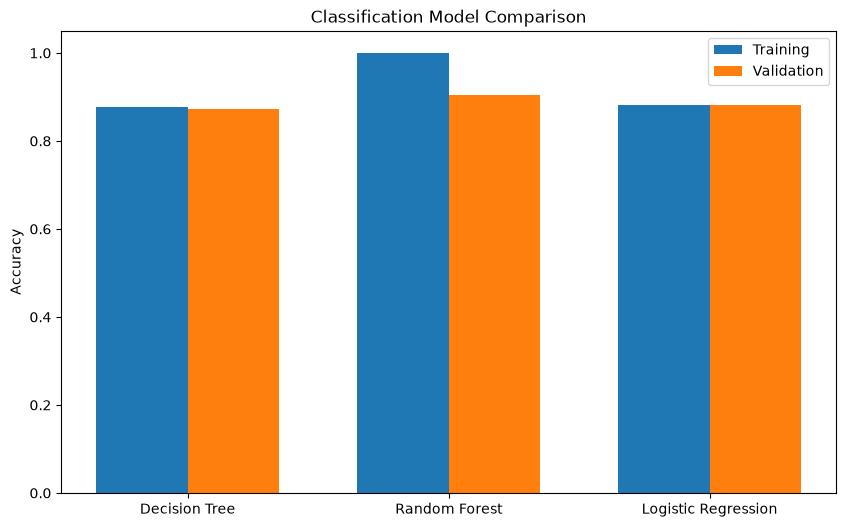

In [22]:
plt.figure(figsize=(10, 6))

x = np.arange(len(classification_results))
width = 0.35

plt.bar(
    x - width / 2,
    classification_results["Training Accuracy"],
    width,
    label="Training"
)

plt.bar(
    x + width / 2,
    classification_results["Validation Accuracy"],
    width,
    label="Validation"
)

plt.xticks(x, classification_results["Model"])
plt.ylabel("Accuracy")
plt.title("Classification Model Comparison")
plt.legend()

plt.show()

## 4.8 Random Forest Hyperparameter Tuning

The initial Random Forest achieved the best validation accuracy among the classification models.

We now tune `n_estimators` and `max_depth` to determine whether a different combination can improve validation performance.

In [23]:
forest_tuning_results = []

for est in [20, 40, 60, 80, 100]:
    for depth in [3, 4, 5, 6, 8, 10]:
        
        model = RandomForestClassifier(
            n_estimators=est,
            max_depth=depth,
            random_state=54321
        )
        
        model.fit(features_train, target_train)
        
        train_accuracy = accuracy_score(
            target_train,
            model.predict(features_train)
        )
        
        valid_accuracy = accuracy_score(
            target_valid,
            model.predict(features_valid)
        )
        
        forest_tuning_results.append({
            "n_estimators": est,
            "max_depth": depth,
            "train_accuracy": train_accuracy,
            "validation_accuracy": valid_accuracy
        })

forest_tuning_results = pd.DataFrame(forest_tuning_results)

print(forest_tuning_results)

    n_estimators  max_depth  train_accuracy  validation_accuracy
0             20          3        0.876411             0.881773
1             20          4        0.887292             0.899015
2             20          5        0.898173             0.892241
3             20          6        0.910080             0.889163
4             20          8        0.934100             0.889163
5             20         10        0.964689             0.895320
6             40          3        0.879696             0.887931
7             40          4        0.887087             0.892241
8             40          5        0.897557             0.895936
9             40          6        0.909054             0.891010
10            40          8        0.935742             0.893473
11            40         10        0.965100             0.892241
12            60          3        0.874974             0.883005
13            60          4        0.888729             0.892857
14            60         

In [24]:
best_forest_tuned = forest_tuning_results.loc[
    forest_tuning_results["validation_accuracy"].idxmax()
]

print("Best tuned Random Forest:")
print(best_forest_tuned)

Best tuned Random Forest:
n_estimators           20.000000
max_depth               4.000000
train_accuracy          0.887292
validation_accuracy     0.899015
Name: 1, dtype: float64


# 5. Regression

The original objective of the dataset is to predict the apartment price represented by `last_price`.

Unlike classification, where the target was converted into two categories, regression predicts the numerical price directly.

We compare a simple baseline against three machine learning models:
- Decision Tree Regressor
- Random Forest Regressor
- Linear Regression

## 5.1 Features and Target

For regression, `last_price` is used directly as the target variable.

The target is scaled by dividing it by 100,000. This changes the numerical scale of the target but does not change the underlying regression problem.

In [25]:
reg_features = df.drop(["last_price", "price_class"], axis=1)
reg_target = df["last_price"] / 100000

print("Features shape:", reg_features.shape)
print("Target shape:", reg_target.shape)

Features shape: (6495, 11)
Target shape: (6495,)


In [26]:
reg_features_train, reg_features_valid, reg_target_train, reg_target_valid = train_test_split(
    reg_features,
    reg_target,
    test_size=0.25,
    random_state=12345
)

print("Training set:", reg_features_train.shape)
print("Validation set:", reg_features_valid.shape)

Training set: (4871, 11)
Validation set: (1624, 11)


## 5.2 Baseline Model

As a baseline, we predict the mean apartment price for every observation.

A machine learning model should provide an improvement over this simple reference.

In [27]:
baseline_prediction = reg_target_train.mean()

baseline_predictions = pd.Series(
    baseline_prediction,
    index=reg_target_valid.index
)

baseline_rmse = mean_squared_error(
    reg_target_valid,
    baseline_predictions
) ** 0.5

print("Baseline RMSE:", baseline_rmse)

Baseline RMSE: 2.6528157161262853


## 5.3 Decision Tree Regressor

A decision tree regressor predicts a numerical target by recursively splitting the data according to feature values.

As with classification, the tree depth controls model complexity. We test several values of `max_depth` to study the trade-off between fitting the training data and generalizing to unseen observations.

In [28]:
tree_regression_results = []

for depth in range(1, 11):
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=12345
    )
    
    model.fit(
        reg_features_train,
        reg_target_train
    )
    
    train_predictions = model.predict(reg_features_train)
    valid_predictions = model.predict(reg_features_valid)
    
    train_rmse = mean_squared_error(
        reg_target_train,
        train_predictions
    ) ** 0.5
    
    valid_rmse = mean_squared_error(
        reg_target_valid,
        valid_predictions
    ) ** 0.5
    
    tree_regression_results.append({
        "max_depth": depth,
        "train_rmse": train_rmse,
        "validation_rmse": valid_rmse
    })

tree_regression_results = pd.DataFrame(tree_regression_results)

print(tree_regression_results)

   max_depth  train_rmse  validation_rmse
0          1    1.917229         2.323018
1          2    1.698616         1.344259
2          3    1.570196         1.333545
3          4    1.364361         1.433556
4          5    0.947176         1.308259
5          6    0.820457         1.297899
6          7    0.728080         1.312012
7          8    0.614319         1.249292
8          9    0.479038         1.423456
9         10    0.382560         1.494179


In [29]:
best_tree = tree_regression_results.loc[
    tree_regression_results["validation_rmse"].idxmin()
]

print("Best Decision Tree Regressor:")
print(best_tree)

Best Decision Tree Regressor:
max_depth          8.000000
train_rmse         0.614319
validation_rmse    1.249292
Name: 7, dtype: float64


## 5.4 Random Forest Regressor

Random Forest combines multiple decision trees to produce a more robust regression model.

We evaluate different combinations of `n_estimators` and `max_depth` and select the model with the lowest validation RMSE.

In [30]:
forest_regression_results = []

for est in [10, 20, 30, 40, 50]:
    for depth in range(1, 11):
        
        model = RandomForestRegressor(
            n_estimators=est,
            max_depth=depth,
            random_state=54321
        )
        
        model.fit(
            reg_features_train,
            reg_target_train
        )
        
        train_predictions = model.predict(reg_features_train)
        valid_predictions = model.predict(reg_features_valid)
        
        train_rmse = mean_squared_error(
            reg_target_train,
            train_predictions
        ) ** 0.5
        
        valid_rmse = mean_squared_error(
            reg_target_valid,
            valid_predictions
        ) ** 0.5
        
        forest_regression_results.append({
            "n_estimators": est,
            "max_depth": depth,
            "train_rmse": train_rmse,
            "validation_rmse": valid_rmse
        })

forest_regression_results = pd.DataFrame(
    forest_regression_results
)

print(forest_regression_results)

    n_estimators  max_depth  train_rmse  validation_rmse
0             10          1    1.801099         2.024173
1             10          2    1.501587         1.894561
2             10          3    1.230984         1.661588
3             10          4    1.109383         1.634346
4             10          5    0.993260         1.614946
5             10          6    0.979413         1.520135
6             10          7    0.850939         1.595289
7             10          8    0.832734         1.517853
8             10          9    0.819685         1.569041
9             10         10    0.774454         1.585814
10            20          1    1.799269         2.122930
11            20          2    1.500900         1.938890
12            20          3    1.216849         1.688867
13            20          4    1.084501         1.668428
14            20          5    0.992422         1.660481
15            20          6    0.918798         1.614717
16            20          7    

In [31]:
best_forest_regression = forest_regression_results.loc[
    forest_regression_results["validation_rmse"].idxmin()
]

print("Best Random Forest Regressor:")
print(best_forest_regression)

Best Random Forest Regressor:
n_estimators       50.000000
max_depth           9.000000
train_rmse          0.691009
validation_rmse     1.453089
Name: 48, dtype: float64


## 5.5 Linear Regression

Linear regression models the target as a linear combination of the input features.

It provides a useful comparison against the tree-based models because it assumes that the relationship between the predictors and apartment price can be represented by a linear function.

In [32]:
linear_model = LinearRegression()

linear_model.fit(
    reg_features_train,
    reg_target_train
)

linear_train_predictions = linear_model.predict(
    reg_features_train
)

linear_valid_predictions = linear_model.predict(
    reg_features_valid
)

linear_train_rmse = mean_squared_error(
    reg_target_train,
    linear_train_predictions
) ** 0.5

linear_valid_rmse = mean_squared_error(
    reg_target_valid,
    linear_valid_predictions
) ** 0.5

print("Training RMSE:", linear_train_rmse)
print("Validation RMSE:", linear_valid_rmse)

Training RMSE: 1.6134114572334404
Validation RMSE: 1.5452013394016322


## 5.6 Regression Model Comparison

The regression models are compared using validation RMSE. Lower RMSE indicates better predictive performance.

The Decision Tree Regressor achieved the lowest validation RMSE among the evaluated models.

In [33]:
regression_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Decision Tree",
        "Random Forest",
        "Linear Regression"
    ],
    "Validation RMSE": [
        baseline_rmse,
        best_tree["validation_rmse"],
        best_forest_regression["validation_rmse"],
        linear_valid_rmse
    ]
})

regression_results["Approx. Error"] = (
    regression_results["Validation RMSE"] * 100000
)

print(regression_results)

               Model  Validation RMSE  Approx. Error
0           Baseline         2.652816  265281.571613
1      Decision Tree         1.249292  124929.159038
2      Random Forest         1.453089  145308.899028
3  Linear Regression         1.545201  154520.133940


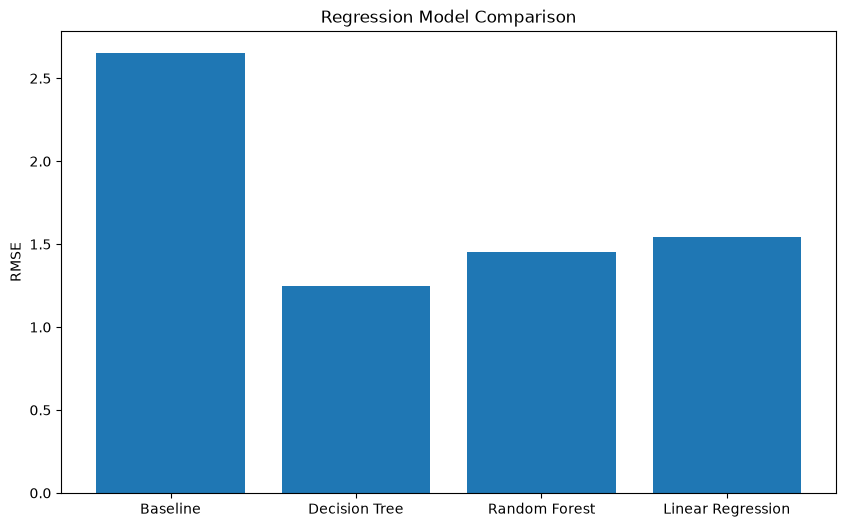

In [34]:
plt.figure(figsize=(10, 6))

plt.bar(
    regression_results["Model"],
    regression_results["Validation RMSE"]
)

plt.ylabel("RMSE")
plt.title("Regression Model Comparison")

plt.show()

### Last Test

In [35]:
extended_tree_results = []

for depth in range(11, 21):
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=12345
    )
    
    model.fit(
        reg_features_train,
        reg_target_train
    )
    
    predictions_valid = model.predict(reg_features_valid)
    
    rmse = mean_squared_error(
        reg_target_valid,
        predictions_valid
    ) ** 0.5
    
    extended_tree_results.append({
        "max_depth": depth,
        "validation_rmse": rmse
    })

extended_tree_results = pd.DataFrame(
    extended_tree_results
)

print(extended_tree_results)

   max_depth  validation_rmse
0         11         1.523129
1         12         1.534971
2         13         1.482742
3         14         1.621515
4         15         1.450076
5         16         1.542393
6         17         1.627781
7         18         1.514338
8         19         1.542880
9         20         1.565495


In [36]:
best_extended_tree = extended_tree_results.loc[
    extended_tree_results["validation_rmse"].idxmin()
]

print("Best tree from depths 11-20:")
print(best_extended_tree)

Best tree from depths 11-20:
max_depth          15.000000
validation_rmse     1.450076
Name: 4, dtype: float64


# 6. Final Model

Based on the validation results, the Decision Tree Regressor with `max_depth=8` achieved the lowest validation RMSE among the evaluated regression models.

We now retrain this model using the complete dataset.

In [37]:
final_model = DecisionTreeRegressor(
    max_depth=8,
    random_state=12345
)

final_model.fit(
    reg_features,
    reg_target
)

print("Final model trained successfully.")

Final model trained successfully.


In [38]:
final_predictions = final_model.predict(reg_features)

final_training_rmse = mean_squared_error(
    reg_target,
    final_predictions
) ** 0.5

print("Final model training RMSE:", final_training_rmse)
print(
    "Approx. training error:",
    final_training_rmse * 100000
)

Final model training RMSE: 0.6030713447307281
Approx. training error: 60307.13447307281


# 7. Feature Importance

Decision trees provide a measure of feature importance based on how much each feature contributes to reducing the impurity of the splits.

We examine these values to identify which apartment characteristics are most influential for the final model.

In [39]:
feature_importance = pd.DataFrame({
    "Feature": reg_features.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

                Feature  Importance
0            total_area    0.711211
7          kitchen_area    0.157373
10  cityCenters_nearest    0.046595
2        ceiling_height    0.028435
9      airports_nearest    0.020295
3          floors_total    0.013665
5                 floor    0.013465
4           living_area    0.007504
1              bedrooms    0.001457
6          bike_parking    0.000000
8               balcony    0.000000


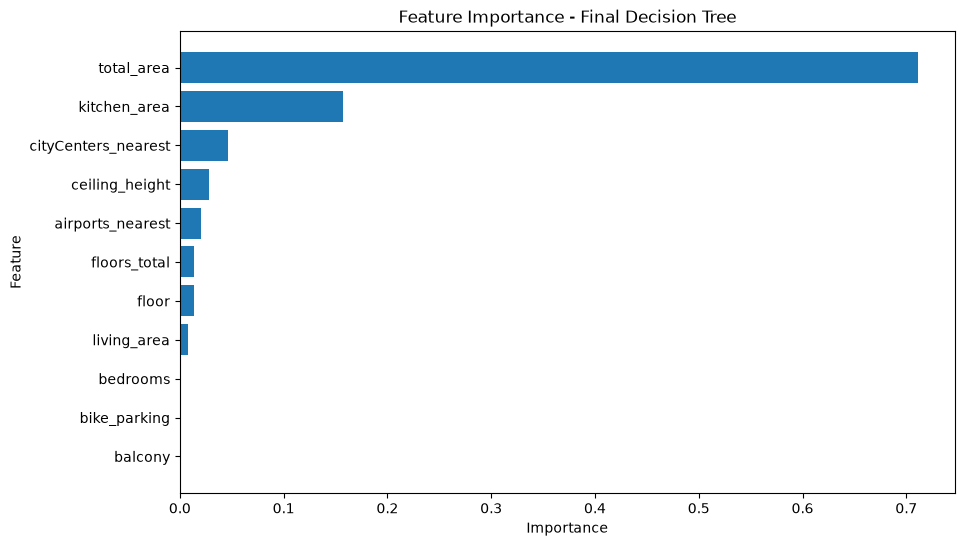

In [40]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Final Decision Tree")

plt.gca().invert_yaxis()

plt.show()

# 8. Predictions vs. Actual Prices

To illustrate the model's performance, we compare actual apartment prices with the predictions generated for observations from the validation set.

These observations were not used to train the final model-selection process.

In [42]:
validation_model = DecisionTreeRegressor(
    max_depth=8,
    random_state=12345
)

validation_model.fit(
    reg_features_train,
    reg_target_train
)

validation_predictions = validation_model.predict(
    reg_features_valid
)

In [43]:
prediction_comparison = pd.DataFrame({
    "Actual Price": reg_target_valid * 100000,
    "Predicted Price": validation_predictions * 100000
})

prediction_comparison["Absolute Error"] = (
    prediction_comparison["Actual Price"] -
    prediction_comparison["Predicted Price"]
).abs()

print(prediction_comparison.head(10))

      Actual Price  Predicted Price  Absolute Error
3316      108000.0     9.232387e+04    15676.125098
4890      103800.0     1.013414e+05     2458.630137
1013      186000.0     2.588932e+05    72893.163125
5507      100000.0     1.035043e+05     3504.322767
6386     1821500.0     1.518370e+06   303130.000000
765       194000.0     2.383863e+05    44386.335630
5102      100000.0     9.142883e+04     8571.168831
4278       89400.0     6.527304e+04    24126.962457
2635       98000.0     8.191996e+04    16080.040791
4319       57900.0     6.943800e+04    11538.000000


In [44]:
validation_rmse_final = mean_squared_error(
    reg_target_valid,
    validation_predictions
) ** 0.5

print("Validation RMSE:", validation_rmse_final)
print(
    "Approx. error in price:",
    validation_rmse_final * 100000
)

Validation RMSE: 1.2492915903767674
Approx. error in price: 124929.15903767674


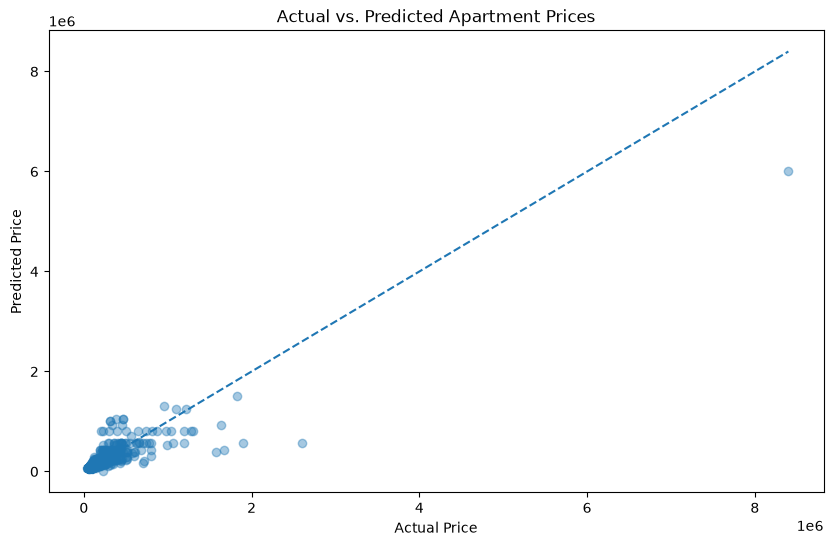

In [45]:
plt.figure(figsize=(10, 6))

plt.scatter(
    prediction_comparison["Actual Price"],
    prediction_comparison["Predicted Price"],
    alpha=0.4
)

# Línea de predicción perfecta
max_price = max(
    prediction_comparison["Actual Price"].max(),
    prediction_comparison["Predicted Price"].max()
)

plt.plot(
    [0, max_price],
    [0, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted Apartment Prices")
plt.show()

# 9. Conclusions

The regression analysis showed that the Decision Tree Regressor achieved the best validation performance among the evaluated regression models.

The best model was a Decision Tree Regressor with `max_depth=8`, achieving a validation RMSE of approximately 1.249, equivalent to an approximate error of $124,929 in the original price scale.

The model performed substantially better than the baseline, which had a validation RMSE of approximately 2.653.

Feature importance analysis showed that `total_area` was the most influential feature, followed by `kitchen_area` and `cityCenters_nearest`.

The actual-vs-predicted plot shows that the model captures the general relationship between apartment characteristics and price, but its predictions become less accurate for some high-priced apartments and extreme observations.

For classification, the Random Forest Classifier achieved the highest validation accuracy, with approximately 90.4%.

Overall, the project demonstrates the use of classification and regression techniques for apartment price analysis, as well as model comparison, hyperparameter selection, evaluation, and feature importance analysis.

In [46]:
classification_results.to_csv(
    "../results/classification_results.csv",
    index=False
)

print("Classification results saved.")

Classification results saved.


In [47]:
regression_results.to_csv(
    "../results/regression_results.csv",
    index=False
)

print("Regression results saved.")

Regression results saved.


In [48]:
feature_importance.to_csv(
    "../results/feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.
